# GumI 

Following is the workflow for studying GumI, from Boltz predictions of the different states to the simulations of each complex and the analysis

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
import MDAnalysis as mda
from MDAnalysis.analysis import rms
from MDAnalysis.analysis import align
import json

## Boltz prediction product


In [28]:
%cd $root/GlucTrans/GumI/Boltz1/product

/mnt/d/PhD/GlucTrans/GumI/Boltz1/product


In [29]:
iptm01 = []
iptm02 = []
iptm12 = []
ciplddt = []
cipde = []
liptm = []
for i in range(10):
    with open(f"confidence_GumI_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        iptm01.append(data['pair_chains_iptm']['0']['1'])
        iptm02.append(data['pair_chains_iptm']['0']['2'])
        iptm12.append(data['pair_chains_iptm']['1']['2'])
        ciplddt.append(data['complex_iplddt'])
        cipde.append(data['complex_ipde'])
        liptm.append(data['ligand_iptm'])
        
        

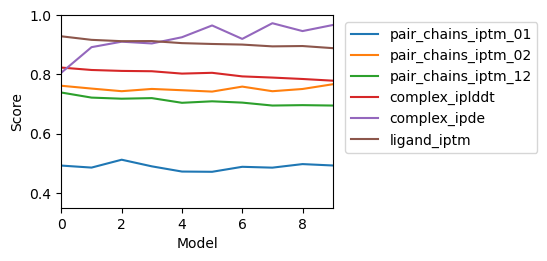

In [30]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(iptm01, label = 'pair_chains_iptm_01')
plt.plot(iptm02,label= 'pair_chains_iptm_02')
plt.plot(iptm12, label = 'pair_chains_iptm_12')
plt.plot(ciplddt, label = 'complex_iplddt')
plt.plot(cipde, label = 'complex_ipde')
plt.plot(liptm, label = 'ligand_iptm')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.xlim(0,9)
plt.ylim(0.35,1.0)
plt.savefig("metrics_plot_prod.png", dpi=600, bbox_inches="tight")

## Boltz prediction full complex


In [31]:
%cd $root/GlucTrans/GumI/Boltz1/full_complex

/mnt/d/PhD/GlucTrans/GumI/Boltz1/full_complex


In [32]:
iptm01 = []
iptm02 = []
iptm12 = []
ciplddt = []
cipde = []
liptm = []
for i in range(10):
    with open(f"confidence_GumI_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        iptm01.append(data['pair_chains_iptm']['0']['1'])
        iptm02.append(data['pair_chains_iptm']['0']['2'])
        iptm12.append(data['pair_chains_iptm']['1']['2'])
        ciplddt.append(data['complex_iplddt'])
        cipde.append(data['complex_ipde'])
        liptm.append(data['ligand_iptm'])
        
        

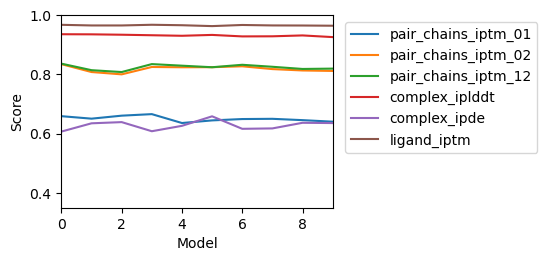

In [34]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(iptm01, label = 'pair_chains_iptm_01')
plt.plot(iptm02,label= 'pair_chains_iptm_02')
plt.plot(iptm12, label = 'pair_chains_iptm_12')
plt.plot(ciplddt, label = 'complex_iplddt')
plt.plot(cipde, label = 'complex_ipde')
plt.plot(liptm, label = 'ligand_iptm')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)


plt.xlim(0,9)
plt.ylim(0.35,1.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_full.png", dpi=600, bbox_inches="tight")

## Boltz prediction free

In [6]:
%cd $root/GlucTrans/GumI/Boltz1/free

/mnt/d/PhD/GlucTrans/GumI/Boltz1/free


In [36]:
ptm = []
plddt = []
pde = []
for i in range(10):
    with open(f"confidence_GumI_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        ptm.append(data['ptm'])
        plddt.append(data['complex_plddt'])
        pde.append(data['complex_pde'])
        
        

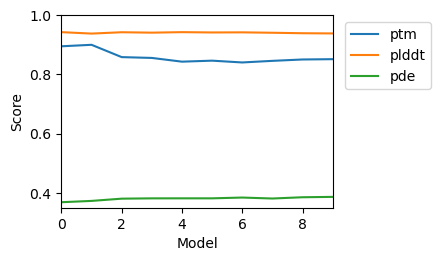

In [37]:
plt.figure(figsize=(3.5, 2.5))

plt.plot(ptm, label = 'ptm')
plt.plot(plddt, label = 'plddt')
plt.plot(pde, label = 'pde')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)
plt.xlim(0,9)
plt.ylim(0.35,1.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_free.png", dpi=600, bbox_inches="tight")

In [19]:
import gemmi
import glob
import re
def idx(f):
    m = re.search(r"GumI_model_(\d+)\.cif$", f)
    return int(m.group(1)) if m else None

cifs = [(idx(f), f) for f in glob.glob("GumI_model_*.cif")]
cifs = sorted([x for x in cifs if x[0] is not None and 0 <= x[0] <= 9], key=lambda x: x[0])

for i, f in cifs:
    st = gemmi.read_structure(f)
    st.write_pdb(f"model_{i}.pdb")

Convertiti: ['model_0.pdb', 'model_1.pdb', 'model_2.pdb', 'model_3.pdb', 'model_4.pdb', 'model_5.pdb', 'model_6.pdb', 'model_7.pdb', 'model_8.pdb', 'model_9.pdb']


In [20]:
from MDAnalysis.analysis.distances import dist
pdbs = sorted(glob.glob("model_[0-9].pdb")) 
assert len(pdbs) == 10, f"Trovati {len(pdbs)} pdb (attesi 10)"


sel1 = "name CA and resid 193"
sel2 = "name CA and resid 61"

distances = []

for f in pdbs:
    u = mda.Universe(f)
    a = u.select_atoms(sel1)
    b = u.select_atoms(sel2)

    if len(a) != 1 or len(b) != 1:
        raise ValueError(f"{f}: selezione non univoca (a={len(a)}, b={len(b)})")

    d = np.linalg.norm(a.positions[0] - b.positions[0])
    distances.append(d)


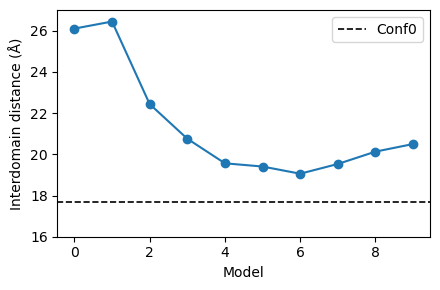

In [23]:
plt.figure(figsize=(4.5, 3.0))
plt.plot(range(10), distances, marker="o")
plt.axhline(17.7, linestyle="--", linewidth=1.2, label=f"Conf0", color='black')

plt.xlabel("Model")
plt.ylabel("Interdomain distance (Å)")
plt.legend()
plt.tight_layout()
plt.ylim(16,27)
plt.savefig("interomdain_prediction_free_gumi.png", dpi=600)
plt.show()

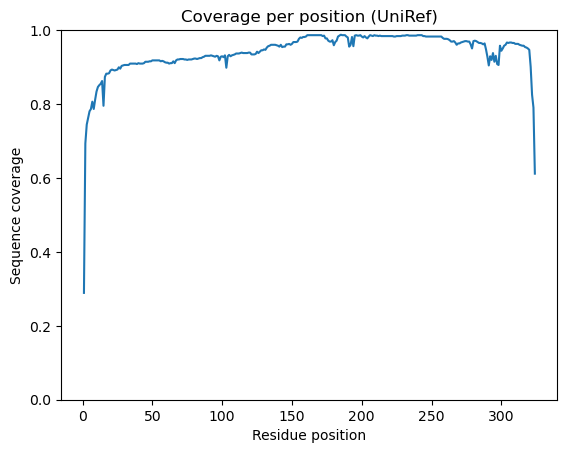

Numero sequenze: 806
Coverage media: 0.9410210458597555


In [7]:
import numpy as np
import matplotlib.pyplot as plt


seqs = []
with open("uniref.a3m") as f:
    seq = ""
    for line in f:
        if line.startswith(">"):
            if seq:
                seqs.append(seq)
            seq = ""
        else:
            seq += line.strip()
    if seq:
        seqs.append(seq)


aligned = [''.join(c for c in s if not c.islower()) for s in seqs]

L = len(aligned[0])
N = len(aligned)


coverage = np.zeros(L)
for i in range(L):
    non_gap = sum(1 for s in aligned if s[i] != '-')
    coverage[i] = non_gap / N


plt.figure()
plt.plot(range(1, L+1), coverage)
plt.ylim(0,1)
plt.xlabel("Residue position")
plt.ylabel("Sequence coverage")
plt.title("Coverage per position (UniRef)")
plt.savefig("coverage_gumi.png", dpi=600)
plt.show()

## Boltz prediction donor

In [38]:
%cd $root/GlucTrans/GumI/Boltz1/donor_substrate

/mnt/d/PhD/GlucTrans/GumI/Boltz1/donor_substrate


In [39]:
iptm01 = []
ciplddt = []
cipde = []
liptm = []
for i in range(10):
    with open(f"confidence_GumI_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        iptm01.append(data['pair_chains_iptm']['0']['1'])
        ciplddt.append(data['complex_iplddt'])
        cipde.append(data['complex_ipde'])
        liptm.append(data['ligand_iptm'])
        

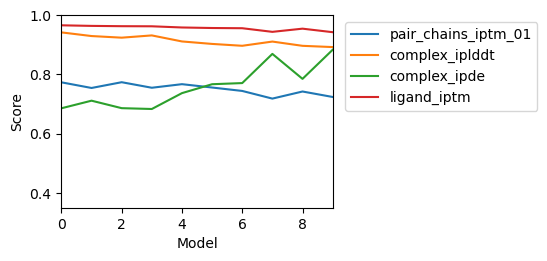

In [40]:
plt.figure(figsize=(3.5, 2.5))

plt.plot(iptm01, label = 'pair_chains_iptm_01')
plt.plot(ciplddt, label = 'complex_iplddt')
plt.plot(cipde, label = 'complex_ipde')
plt.plot(liptm, label = 'ligand_iptm')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.xlim(0,9)
plt.ylim(0.35,1.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_donor.png", dpi=600, bbox_inches="tight")

In [25]:
import gemmi
import glob
import re
def idx(f):
    m = re.search(r"GumI_model_(\d+)\.cif$", f)
    return int(m.group(1)) if m else None

cifs = [(idx(f), f) for f in glob.glob("GumI_model_*.cif")]
cifs = sorted([x for x in cifs if x[0] is not None and 0 <= x[0] <= 9], key=lambda x: x[0])

for i, f in cifs:
    st = gemmi.read_structure(f)
    st.write_pdb(f"model_{i}.pdb")

Convertiti: ['model_0.pdb', 'model_1.pdb', 'model_2.pdb', 'model_3.pdb', 'model_4.pdb', 'model_5.pdb', 'model_6.pdb', 'model_7.pdb', 'model_8.pdb', 'model_9.pdb']


In [26]:
from MDAnalysis.analysis.distances import dist
pdbs = sorted(glob.glob("model_[0-9].pdb"))  # prende 0..9
assert len(pdbs) == 10, f"Trovati {len(pdbs)} pdb (attesi 10)"

# Selezioni: cambia i resid!
sel1 = "name CA and resid 193"
sel2 = "name CA and resid 61"

distances = []

for f in pdbs:
    u = mda.Universe(f)
    a = u.select_atoms(sel1)
    b = u.select_atoms(sel2)

    if len(a) != 1 or len(b) != 1:
        raise ValueError(f"{f}: selezione non univoca (a={len(a)}, b={len(b)})")

    d = np.linalg.norm(a.positions[0] - b.positions[0])
    distances.append(d)


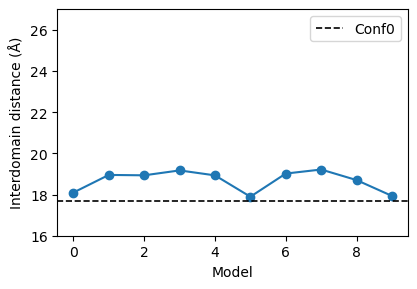

In [27]:
plt.figure(figsize=(4.5, 3.0))
plt.plot(range(10), distances, marker="o")
plt.axhline(17.7, linestyle="--", linewidth=1.2, label=f"Conf0", color='black')

plt.xlabel("Model")
plt.ylabel("Interdomain distance (Å)")
plt.legend()
plt.tight_layout()
plt.ylim(16,27)
plt.savefig("interomdain_prediction_donor_gumi.png", dpi=600)
plt.show()

## ANM


### Conf0

In [37]:
from prody import *

In [38]:
gumi=parsePDB('closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.06s.


In [21]:
gumi_anm = exANM('gumi_exanm')
gumi_anm

<exANM: gumi_exanm (0 modes; 0 nodes)>

In [22]:
gumi_ca = gumi.ca
gumi_ca

<Selection: 'ca' from closed_gumi (324 atoms)>

In [9]:
gumi_anm.buildMembrane(gumi_ca, membrane_high = 5, membrane_low = -20 , hull= False, lat = 'FCC' )

@> Membrane was built in  1s.


array([[  9.022     , -24.285     , -33.398     ],
       [  6.201     , -23.193     , -31.072     ],
       [  5.86      , -19.402     , -31.077     ],
       ...,
       [-52.60874452,  56.99280656,   4.38406204],
       [-48.22468248,  61.37686861,   4.38406204],
       [-43.84062043,  65.76093065,   4.38406204]])

In [10]:
a =gumi_anm.getMembrane()

In [11]:
writePDB('memb_fcc_2.pdb', a)

'memb_fcc_2.pdb'

In [12]:
gumi_anm.buildHessian(gumi_ca)
gumi_anm.calcModes()

@> layers: [0 1 2 3]
@> max layer: 3
@> layer: 0
@> layer: 1
@> layer: 2
@> layer: 3
@> layer: 3 finished
@> layer: 2 finished
@> layer: 1 finished
@> layer: 0 finished
@> Hessian was built in 29.23s.
@> 20 modes were calculated in 0.48s.


In [13]:
writeNMD('gumi_anm.nmd', gumi_anm, gumi_ca)

'gumi_anm.nmd'

In [40]:
saveModel(gumi_anm)

'gumi_exanm.exanm.npz'

In [39]:
gumi_anm = ANM('gumi_exanm')
gumi_anm

<ANM: gumi_exanm (0 modes; 0 nodes)>

In [40]:
gumi_ca = gumi.ca
gumi_ca

<Selection: 'ca' from closed_gumi (324 atoms)>

In [41]:
gumi_anm.buildHessian(gumi_ca)
gumi_anm.calcModes()

@> Hessian was built in 0.09s.
@> 20 modes were calculated in 0.07s.


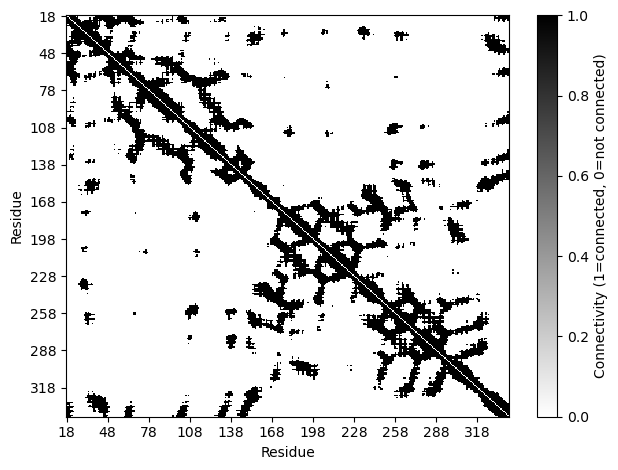

In [43]:
matrix = gumi_anm.getKirchhoff()

N = matrix.shape[0]
start_res = 18
residue_numbers = np.arange(start_res, start_res + N)

mask = np.eye(matrix.shape[0], dtype=bool)
masked_kirchhoff = np.ma.array(matrix, mask=mask)

plt.imshow(-masked_kirchhoff, cmap='gray_r', interpolation='nearest', aspect='auto')
plt.colorbar(label='Connectivity (1=connected, 0=not connected)')

step = 30
ticks = np.arange(0, N, step) 
tick_labels = residue_numbers[ticks]  

plt.xticks(ticks, tick_labels)
plt.yticks(ticks, tick_labels)

plt.xlabel('Residue')
plt.ylabel('Residue')

plt.tight_layout()
plt.savefig(
    "gumi_anm_matrix_closed.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


### model0

In [45]:
from prody import *

In [46]:
gumi=parsePDB('model0out.pdb')

@> 2591 atoms and 1 coordinate set(s) were parsed in 0.05s.


In [14]:
gumi_anm = exANM('gumi_exanm')
gumi_anm

<exANM: gumi_exanm (0 modes; 0 nodes)>

In [15]:
gumi_ca = gumi.ca
gumi_ca

<Selection: 'ca' from model0out (324 atoms)>

In [16]:
gumi_anm.buildMembrane(gumi_ca, membrane_high = 5, membrane_low = -20 , hull= False, lat = 'FCC' )

@> Membrane was built in  1s.


array([[ 18.28      , -14.416     , -30.706     ],
       [ 14.855     , -15.03      , -29.23      ],
       [ 12.464     , -12.249     , -30.214     ],
       ...,
       [-52.60874452,  56.99280656,   4.38406204],
       [-48.22468248,  61.37686861,   4.38406204],
       [-43.84062043,  65.76093065,   4.38406204]])

In [17]:
a =gumi_anm.getMembrane()

In [18]:
writePDB('memb_fcc_2.pdb', a)

'memb_fcc_2.pdb'

In [19]:
gumi_anm.buildHessian(gumi_ca)
gumi_anm.calcModes()

@> layers: [0 1 2 3]
@> max layer: 3
@> layer: 0
@> layer: 1
@> layer: 2
@> layer: 3
@> layer: 3 finished
@> layer: 2 finished
@> layer: 1 finished
@> layer: 0 finished
@> Hessian was built in 16.81s.
@> 20 modes were calculated in 0.39s.


In [20]:
writeNMD('gumi_anm.nmd', gumi_anm, gumi_ca)

'gumi_anm.nmd'

In [21]:
saveModel(gumi_anm)

'gumi_exanm.exanm.npz'

In [47]:
gumi_anm = ANM('gumi_exanm')
gumi_anm

<ANM: gumi_exanm (0 modes; 0 nodes)>

In [48]:
gumi_ca = gumi.ca
gumi_ca

<Selection: 'ca' from model0out (324 atoms)>

In [49]:
gumi_anm.buildHessian(gumi_ca)
gumi_anm.calcModes()

@> Hessian was built in 0.08s.
@> 20 modes were calculated in 0.41s.


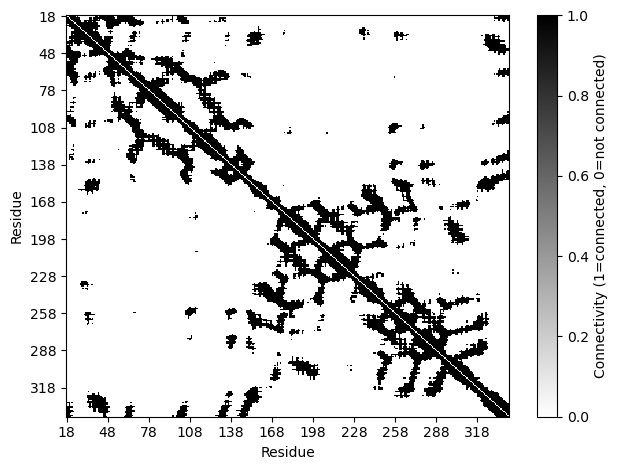

In [50]:
matrix = gumi_anm.getKirchhoff()

N = matrix.shape[0]
start_res = 18
residue_numbers = np.arange(start_res, start_res + N)

mask = np.eye(matrix.shape[0], dtype=bool)
masked_kirchhoff = np.ma.array(matrix, mask=mask)

plt.imshow(-masked_kirchhoff, cmap='gray_r', interpolation='nearest', aspect='auto')
plt.colorbar(label='Connectivity (1=connected, 0=not connected)')

step = 30
ticks = np.arange(0, N, step) 
tick_labels = residue_numbers[ticks]  

plt.xticks(ticks, tick_labels)
plt.yticks(ticks, tick_labels)

plt.xlabel('Residue')
plt.ylabel('Residue')
plt.tight_layout()
plt.savefig(
    "gumi_anm_matrix_opened.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## ClustENMD

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [6]:
structure = parsePDB('./rep1/closed_gumi_fixed.pdb')
dcd1 = parseDCD('./rep1/ensemble.dcd')
dcd2 = parseDCD('./rep2/ensemble.dcd')
dcd3 = parseDCD('./rep3/ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.09s.
@> DCD file contains 4651 coordinate sets for 5208 atoms.
@> DCD file was parsed in 2.36 seconds.
@> 277.56 MB parsed at input rate 117.58 MB/s.
@> 4651 coordinate sets parsed at input rate 1970 frame/s.
@> DCD file contains 4647 coordinate sets for 5208 atoms.
@> DCD file was parsed in 1.85 seconds.
@> 277.32 MB parsed at input rate 150.16 MB/s.
@> 4647 coordinate sets parsed at input rate 2516 frame/s.
@> DCD file contains 4648 coordinate sets for 5208 atoms.
@> DCD file was parsed in 4.53 seconds.
@> 277.38 MB parsed at input rate 61.23 MB/s.
@> 4648 coordinate sets parsed at input rate 1026 frame/s.


In [7]:
dcd1.setCoords(structure)
dcd2.setCoords(structure)
dcd3.setCoords(structure)

In [8]:
dcd1.setAtoms(structure.calpha)
dcd2.setAtoms(structure.calpha)
dcd3.setAtoms(structure.calpha)

In [11]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.06s.


In [12]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1] + [frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd2] + [frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd3])  

In [13]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [14]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [15]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [16]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1] + [calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd2] + [calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd3] )

In [17]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

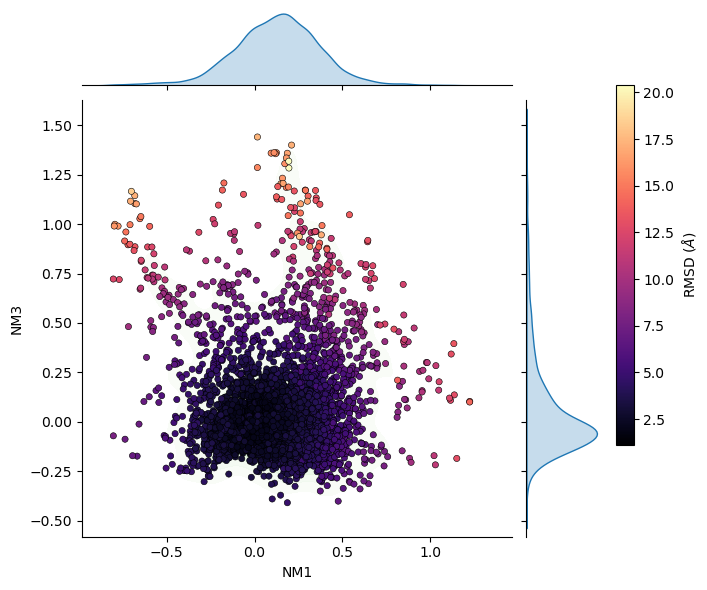

In [18]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Full Complex model 0 product 


### ANM Projection

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [9]:
structure = parsePDB('ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.06s.
@> DCD file contains 5001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 1.86 seconds.
@> 298.45 MB parsed at input rate 160.61 MB/s.
@> 5001 coordinate sets parsed at input rate 2691 frame/s.


In [10]:
dcd1.setCoords(structure)

In [11]:
dcd1.setAtoms(structure.calpha)

In [12]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [13]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [14]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [15]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [16]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [17]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [18]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

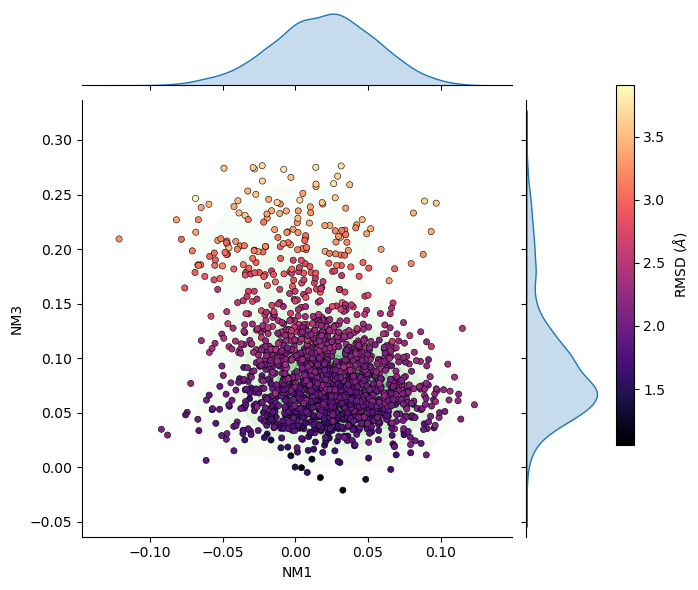

In [19]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Reactive distance 

In [5]:
from MDAnalysis.analysis import distances
u = mda.Universe("./ref_vis.pdb", "md_mol.xtc")

In [6]:
atom1 = u.select_atoms("id 5481")
atom2 = u.select_atoms("id 5440")

In [7]:
distanze = []

for ts in u.trajectory:
    d = distances.dist(atom1, atom2, box=u.dimensions)[2]
    distanze.append(d[0])

np.save("gumi_full_reactive_dist_rep0.npy", np.array(distanze))

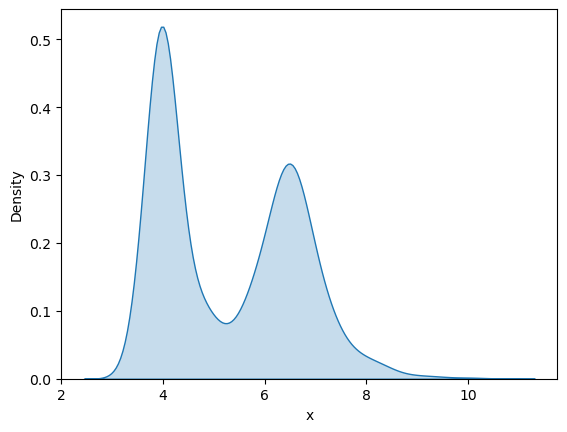

In [8]:
import seaborn as sns
sns.kdeplot(distanze, fill=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

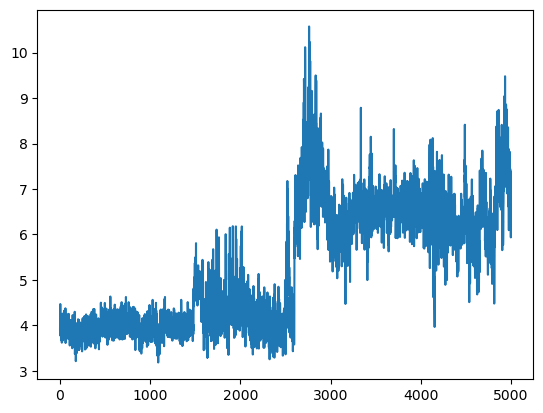

In [9]:
plt.plot(distanze)

## Full complex Rep1

### ANM Projection

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [22]:
structure = parsePDB('../PROD/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> DCD file contains 5001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 1.92 seconds.
@> 298.45 MB parsed at input rate 155.46 MB/s.
@> 5001 coordinate sets parsed at input rate 2605 frame/s.


In [23]:
dcd1.setCoords(structure)

In [24]:
dcd1.setAtoms(structure.calpha)

In [25]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [26]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [27]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [28]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [29]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [30]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [31]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

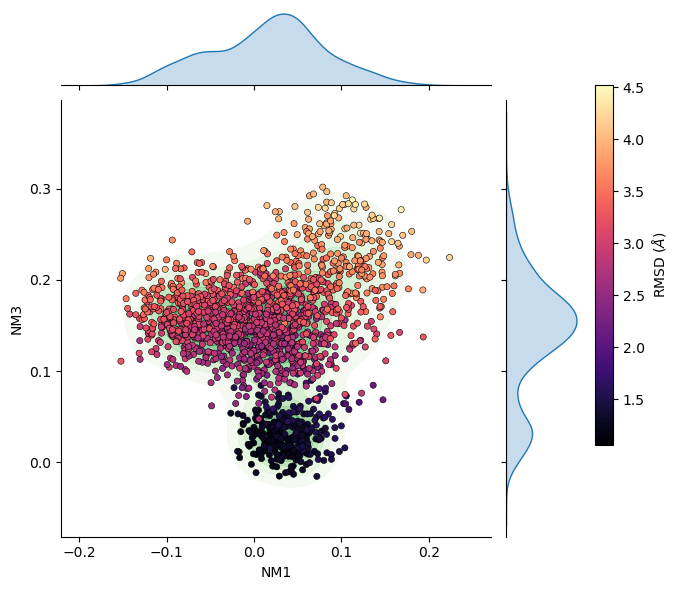

In [32]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Reactive distance 

In [11]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [12]:
atom1 = u.select_atoms("id 5481")
atom2 = u.select_atoms("id 5440")

In [13]:
distanze = []

for ts in u.trajectory:
    d = distances.dist(atom1, atom2, box=u.dimensions)[2]
    distanze.append(d[0])

np.save("gumi_full_reactive_dist_rep1.npy", np.array(distanze))

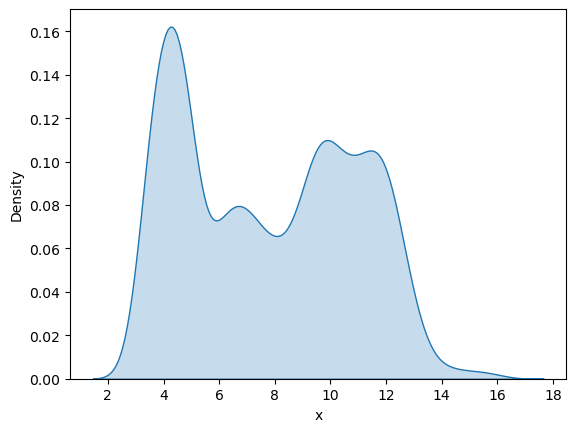

In [14]:
import seaborn as sns
sns.kdeplot(distanze, fill=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

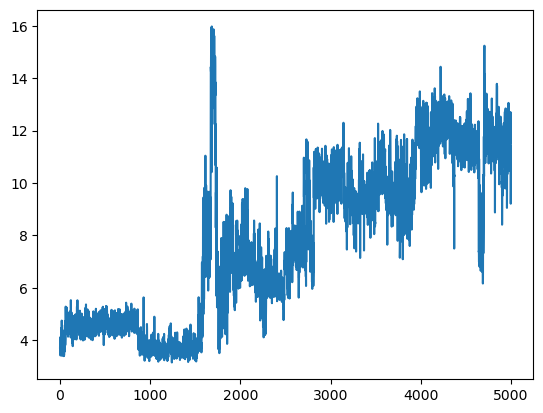

In [15]:
plt.plot(distanze)

## Full complex Rep2

### ANM Projection

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [35]:
structure = parsePDB('../PROD/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> DCD file contains 5001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 2.00 seconds.
@> 298.45 MB parsed at input rate 149.43 MB/s.
@> 5001 coordinate sets parsed at input rate 2503 frame/s.


In [36]:
dcd1.setCoords(structure)

In [37]:
dcd1.setAtoms(structure.calpha)

In [38]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.03s.


In [39]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [40]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [41]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [42]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [43]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [44]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

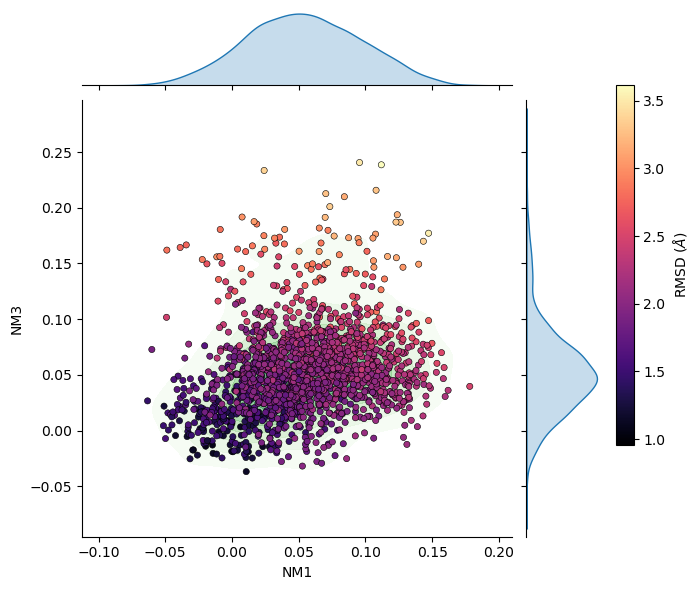

In [45]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Reactive distance 

In [17]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [18]:
atom1 = u.select_atoms("id 5481")
atom2 = u.select_atoms("id 5440")

In [19]:
distanze = []

for ts in u.trajectory:
    d = distances.dist(atom1, atom2, box=u.dimensions)[2]
    distanze.append(d[0])

np.save("gumi_full_reactive_dist_rep2.npy", np.array(distanze))

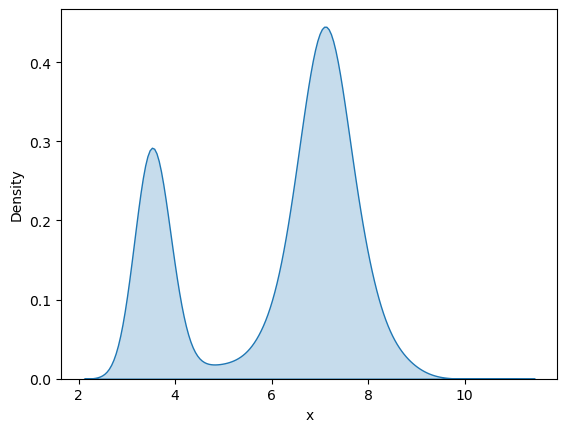

In [20]:
import seaborn as sns
sns.kdeplot(distanze, fill=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

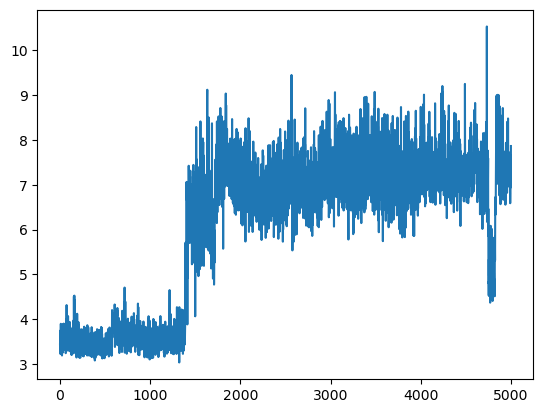

In [21]:
plt.plot(distanze)

## Free model 0 

### ANM Projection

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [63]:
structure = parsePDB('./ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.08s.
@> DCD file contains 10001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 3.00 seconds.
@> 596.83 MB parsed at input rate 199.19 MB/s.
@> 10001 coordinate sets parsed at input rate 3337 frame/s.


In [64]:
dcd1.setCoords(structure)

In [65]:
dcd1.setAtoms(structure.calpha)

In [66]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.03s.


In [67]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [68]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [69]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [70]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [71]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [72]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

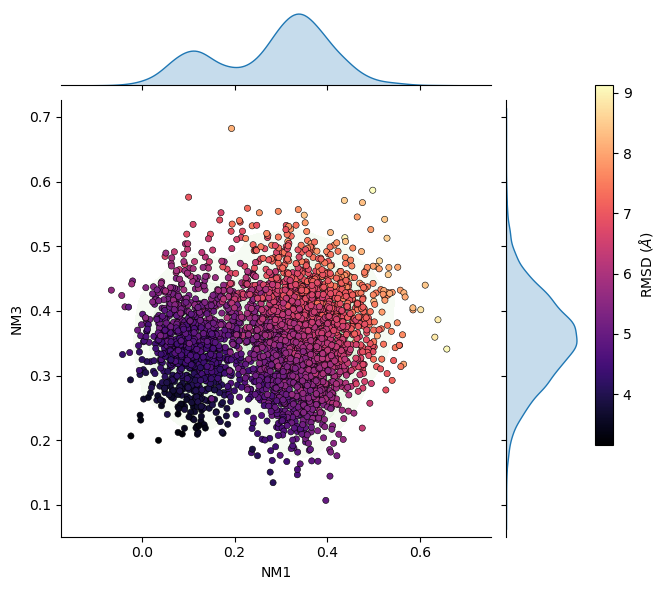

In [73]:

g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [24]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:133 309:324 and name CA",
    "LINKER": "resid 134:152 296:308 and name CA",
    "C":      "resid 153:295 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = "ref_protein.pdb"
traj = "ensemble.dcd"

rmsf_map = {} 

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


N: n_atoms=149  rmsf min/max=0.420/3.582
LINKER: n_atoms=32  rmsf min/max=0.657/1.704
C: n_atoms=143  rmsf min/max=0.365/1.976
TOTAL residues: 324 RMSF min/max: 0.3648849535606324 3.5816955319001194
Saved intradomain_rmsf_CA.npz


## Free model Rep1



### ANM Projection

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [9]:
structure = parsePDB('../../PROD2/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.09s.
@> DCD file contains 10001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 12.16 seconds.
@> 596.83 MB parsed at input rate 49.08 MB/s.
@> 10001 coordinate sets parsed at input rate 822 frame/s.


In [10]:
dcd1.setCoords(structure)

In [11]:
dcd1.setAtoms(structure.calpha)

In [12]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.14s.


In [13]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [14]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [15]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [16]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [17]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [18]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

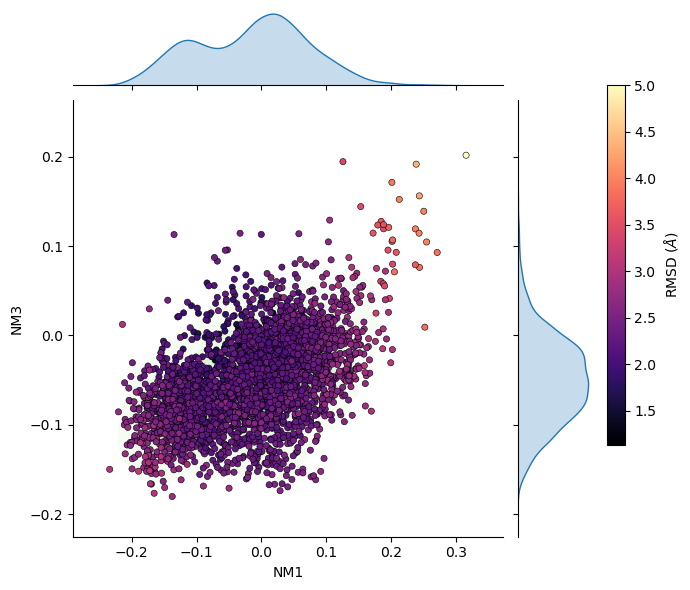

In [19]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Free model Rep2



### ANM Projection

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [23]:
structure = parsePDB('../../PROD2/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.43s.
@> DCD file contains 10001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 22.45 seconds.
@> 596.83 MB parsed at input rate 26.59 MB/s.
@> 10001 coordinate sets parsed at input rate 445 frame/s.


In [24]:
dcd1.setCoords(structure)

In [25]:
dcd1.setAtoms(structure.calpha)

In [26]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.25s.


In [27]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [28]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [29]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [30]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [31]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [32]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

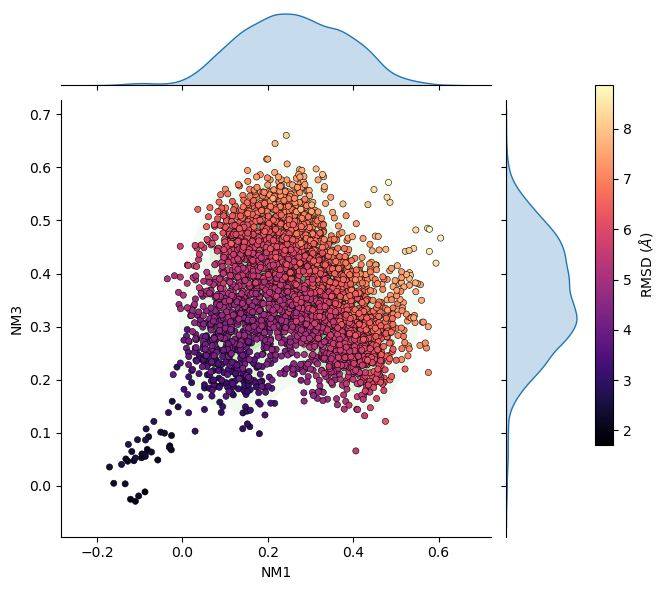

In [33]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Free conf0



### ANM Projection

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [12]:
structure = parsePDB('./ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.12s.
@> DCD file contains 10001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 3.00 seconds.
@> 596.83 MB parsed at input rate 198.72 MB/s.
@> 10001 coordinate sets parsed at input rate 3329 frame/s.


In [13]:
dcd1.setCoords(structure)

In [14]:
dcd1.setAtoms(structure.calpha)

In [15]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.03s.


In [16]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [17]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [18]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [19]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [20]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [21]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

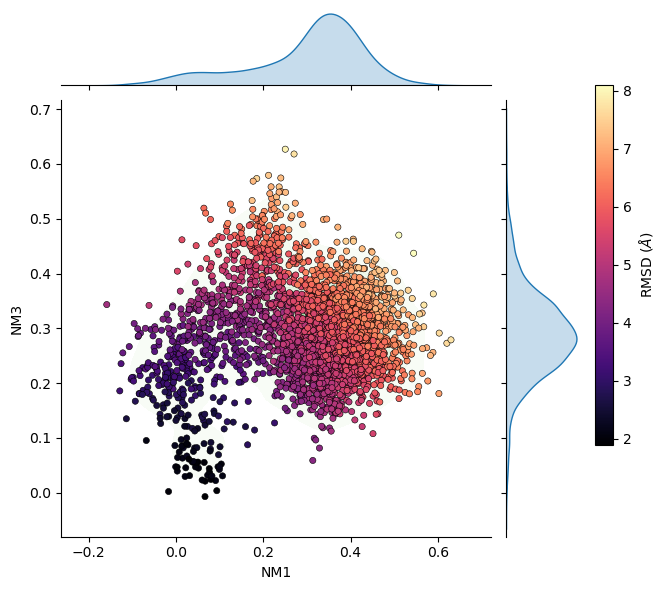

In [22]:

g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [4]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:133 309:324 and name CA",
    "LINKER": "resid 134:152 296:308 and name CA",
    "C":      "resid 153:295 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = "ref_protein.pdb"
traj = "ensemble.dcd"

rmsf_map = {} 

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


N: n_atoms=149  rmsf min/max=0.387/3.414
LINKER: n_atoms=32  rmsf min/max=0.517/1.482
C: n_atoms=143  rmsf min/max=0.349/2.389
TOTAL residues: 324 RMSF min/max: 0.3491818766215503 3.4136083035691844
Saved intradomain_rmsf_CA.npz


## Free conf0 rep1


### ANM Projection

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [30]:
structure = parsePDB('../../UMD_rep0/PROD2/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.09s.
@> DCD file contains 10001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 3.04 seconds.
@> 596.83 MB parsed at input rate 196.20 MB/s.
@> 10001 coordinate sets parsed at input rate 3287 frame/s.


In [31]:
dcd1.setCoords(structure)

In [32]:
dcd1.setAtoms(structure.calpha)

In [33]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.03s.


In [34]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [35]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [36]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [37]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [38]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [39]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

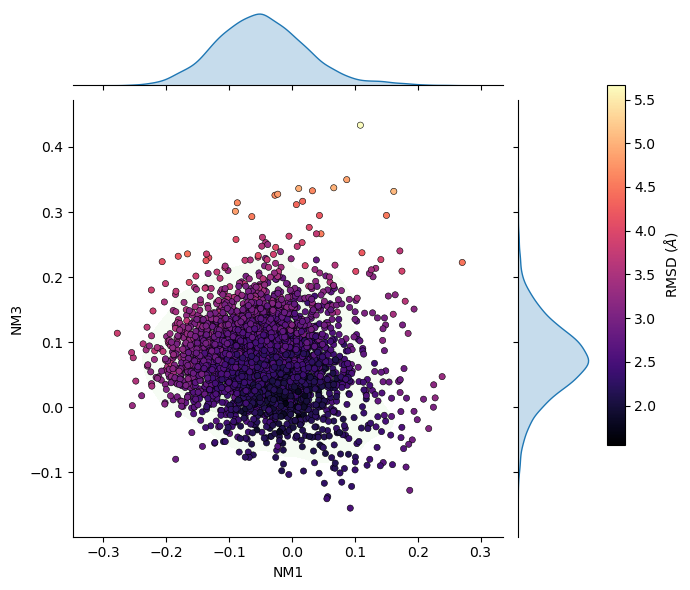

In [40]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [27]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:133 309:324 and name CA",
    "LINKER": "resid 134:152 296:308 and name CA",
    "C":      "resid 153:295 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = '../../UMD_rep0/PROD2/ref_protein.pdb'
traj = "ensemble.dcd"

rmsf_map = {} 

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


N: n_atoms=149  rmsf min/max=0.428/3.364
LINKER: n_atoms=32  rmsf min/max=0.735/1.456
C: n_atoms=143  rmsf min/max=1.037/8.855
TOTAL residues: 324 RMSF min/max: 0.4276211769701909 8.85538827053226
Saved intradomain_rmsf_CA.npz


## Free conf0 rep2

### ANM Projection

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [47]:
structure = parsePDB('../../UMD_rep0/PROD2/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.08s.
@> DCD file contains 10001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 3.30 seconds.
@> 596.83 MB parsed at input rate 180.76 MB/s.
@> 10001 coordinate sets parsed at input rate 3029 frame/s.


In [48]:
dcd1.setCoords(structure)

In [49]:
dcd1.setAtoms(structure.calpha)

In [50]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [51]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [52]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [53]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [54]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [55]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [56]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

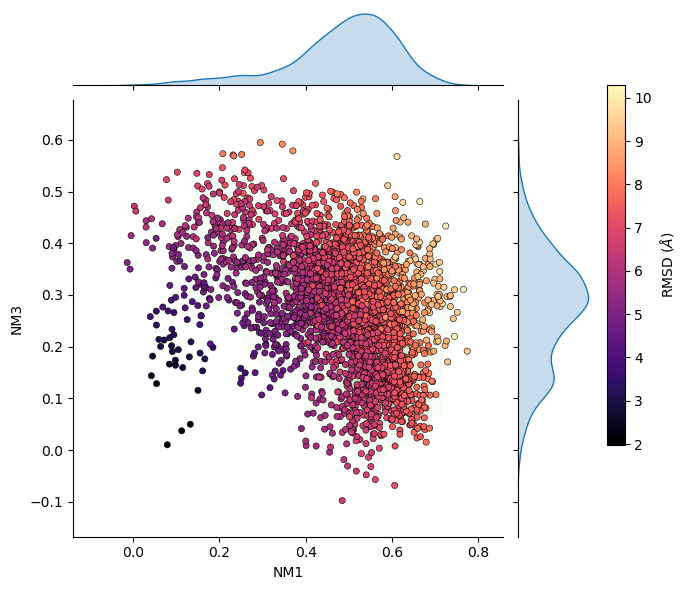

In [57]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Donor 


### ANM Projection

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [25]:
structure = parsePDB('./ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.05s.
@> DCD file contains 5001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 1.58 seconds.
@> 298.45 MB parsed at input rate 188.71 MB/s.
@> 5001 coordinate sets parsed at input rate 3162 frame/s.


In [26]:
dcd1.setCoords(structure)

In [27]:
dcd1.setAtoms(structure.calpha)

In [31]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.02s.


In [32]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [33]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [34]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [35]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [36]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [37]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

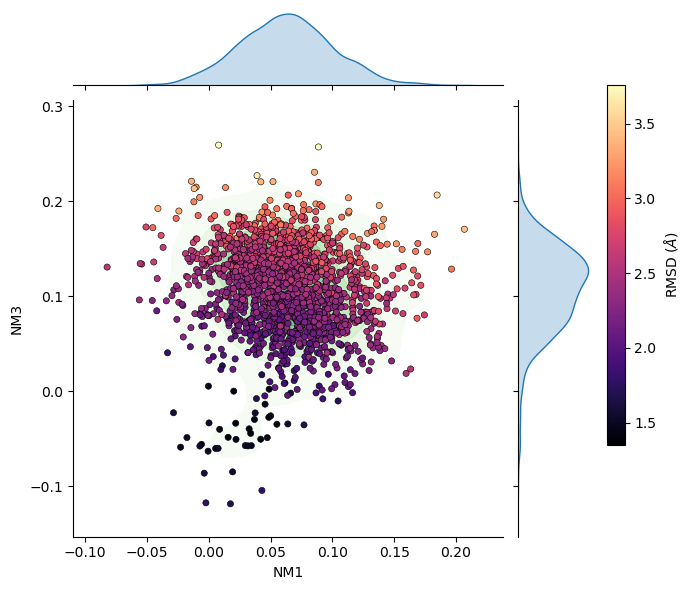

In [38]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Contacts

In [54]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [55]:
protein = u.select_atoms("protein")
substrate = u.select_atoms("resname AMAN")

In [56]:
from MDAnalysis.analysis import contacts
ca = contacts.Contacts(
    u,
    select=(protein, substrate),
    refgroup=(protein, substrate),
    radius=4.5  # Å
)
ca.run()

Q = ca.results.timeseries[:,1]
np.save("native_contacts_Q_rep0.npy", Q)

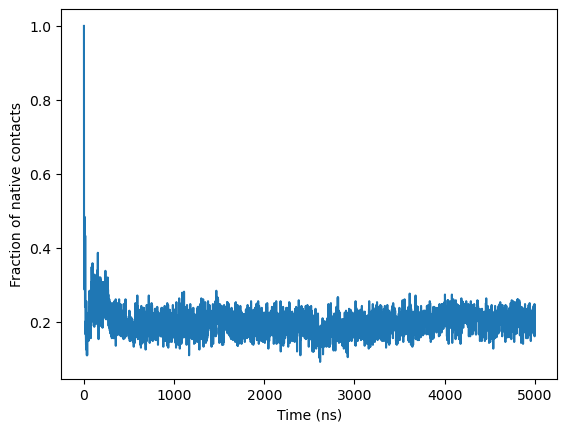

In [52]:
plt.plot( Q)  # ps → ns
plt.xlabel("Time (ns)")
plt.ylabel("Fraction of native contacts")
plt.show()

## Donor rep 1

### ANM Projection

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [42]:
structure = parsePDB('../PROD/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5208 atoms and 1 coordinate set(s) were parsed in 0.06s.
@> DCD file contains 5001 coordinate sets for 5208 atoms.
@> DCD file was parsed in 1.47 seconds.
@> 298.45 MB parsed at input rate 203.65 MB/s.
@> 5001 coordinate sets parsed at input rate 3412 frame/s.


In [43]:
dcd1.setCoords(structure)

In [44]:
dcd1.setAtoms(structure.calpha)

In [45]:
ref_struct = parsePDB(f'closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.02s.


In [46]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [47]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [48]:
gumh_anm = loadModel(f"gumi_exanm.exanm.npz")

In [49]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [50]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [51]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

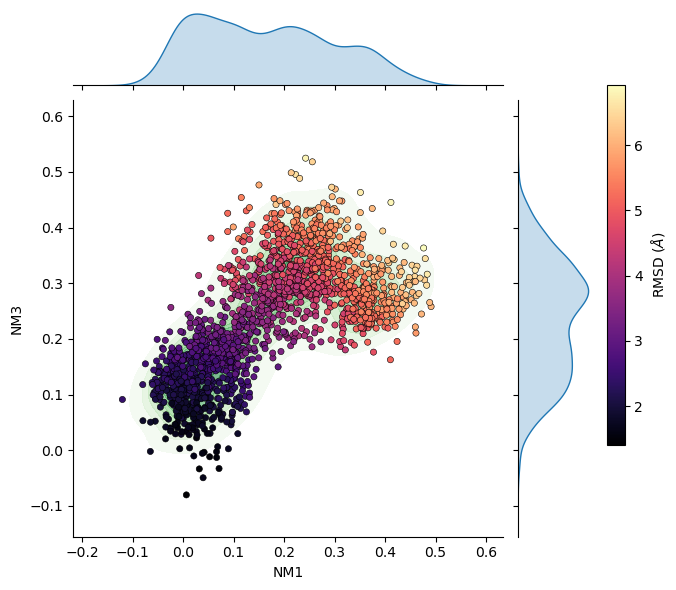

In [52]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Contacts

In [58]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [59]:
protein = u.select_atoms("protein")
substrate = u.select_atoms("resname AMAN")

In [60]:
from MDAnalysis.analysis import contacts
ca = contacts.Contacts(
    u,
    select=(protein, substrate),
    refgroup=(protein, substrate),
    radius=4.5  # Å
)
ca.run()

Q = ca.results.timeseries[:,1]
np.save("native_contacts_Q_rep0.npy", Q)

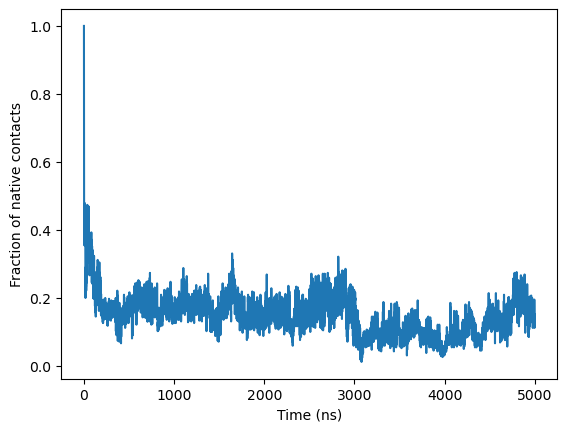

In [41]:
plt.plot( Q)  # ps → ns
plt.xlabel("Time (ns)")
plt.ylabel("Fraction of native contacts")
plt.show()

## Donor rep 2

### ANM Projection

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [27]:
structure = parsePDB('../PROD/ref_protein.pdb')
dcd1 = parseDCD('ensemble.dcd')

NameError: name 'parsePDB' is not defined

In [53]:
dcd1.setCoords(structure)

In [54]:
dcd1.setAtoms(structure.calpha)

In [55]:
ref_struct = parsePDB(f'{root}/GlucTrans/GumI/Boltz1/ANM/closed_gumi.pdb')

@> 2592 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [56]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [57]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [58]:
gumh_anm = loadModel(f"{root}/GlucTrans/GumI/Boltz1/ANM/gumi_exanm.exanm.npz")

In [59]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [60]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [61]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

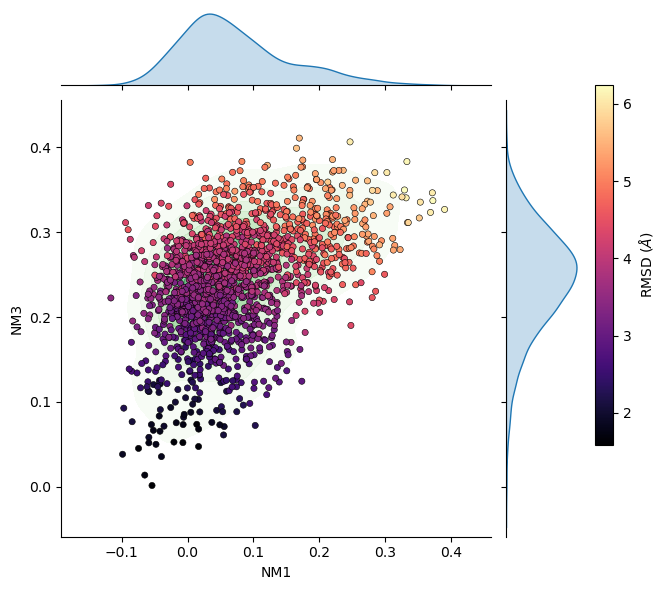

In [62]:
# Creiamo il JointPlot con KDE
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)


# Aggiungiamo il grafico a dispersione
scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 





# Creiamo una nuova figura per la barra dei colori per posizionarla fuori dal grafico
# Usiamo un nuovo asse solo per la barra dei colori
cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  # Posizione e dimensioni della barra dei colori
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [29]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [30]:
def get_normal_vector(coords):
    geometric_center = np.mean(coords, axis=0)
    traslated_coords = coords - geometric_center
    N = len(coords)
    R_prime = np.zeros(3)
    R_double_prime = np.zeros(3)
    for j in range(N):
        R_prime += traslated_coords[j] * np.cos(2 * np.pi * j / N)
        R_double_prime += traslated_coords[j] * np.sin(2 * np.pi * j / N)
    normal_vector = np.cross(R_prime, R_double_prime)
    normal_vector /= np.linalg.norm(normal_vector)  
    return normal_vector

In [31]:
def cartesian_to_spherical(cartesian_coords):
    x, y, z = cartesian_coords
    r = np.linalg.norm(cartesian_coords)  
    phi = np.degrees(np.arctan2(y, x))  
    theta = np.degrees(np.arccos(z / r)) 
    return (phi, theta, r)

In [33]:
u = mda.Universe('../PROD/ref_donor_domain.pdb', 'donor_domain.dcd')
reference = mda.Universe('../PROD/ref_bb.pdb')
reference_frame = reference.select_atoms('backbone').positions.copy()
reference_all=reference.select_atoms('all')
align.AlignTraj(u, reference, select='backbone', in_memory=True).run()
normal_vectors=[]
for ts in u.trajectory:
    ring=u.select_atoms('id 5253 5245 5254 5258 5262 5251')
    coords=ring.positions
    normal_vectors.append(get_normal_vector(coords))

np.savetxt('normal_vectors.txt', normal_vectors, header='Nx Ny Nz', comments='#')
ca_atoms=reference.select_atoms('name CA')
projections=[]
for i in range(len(normal_vectors)):
    projections.append(np.dot(ca_atoms.principal_axes(), normal_vectors[i]))
projections=np.array(projections)
polar=[]
for i in projections:
    polar.append(cartesian_to_spherical(i))

polar=np.array(polar).transpose()
phi, theta, r = polar
polar_system=np.array([phi, theta]).transpose()
df_polar = pd.DataFrame(
    polar_system,
    columns=["phi", "theta"]
)

df_polar.to_csv(
    "polar_data.csv",
    index=False
)

In [34]:
df_rep0 = pd.read_csv('polar_data.csv') 
df_rep0

,phi,theta
0,-39.038621,87.740860
1,58.334833,75.191054
2,55.323998,73.003473
3,73.993070,66.175579
4,61.937367,58.066906
...,...,...
4997,-113.544935,58.092556
4998,-167.338375,2.566456
4999,-95.118507,61.977692
5000,-131.063008,39.070405


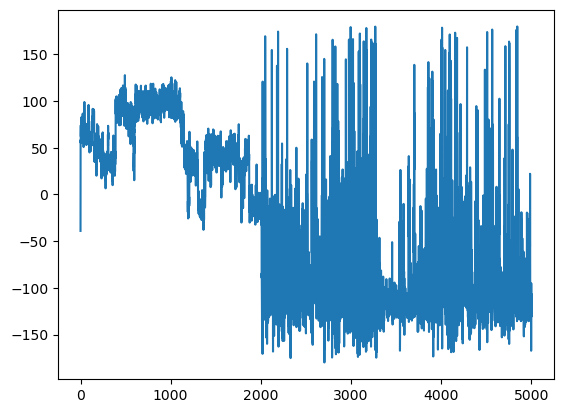

In [35]:
plt.plot(df_rep0['phi'])

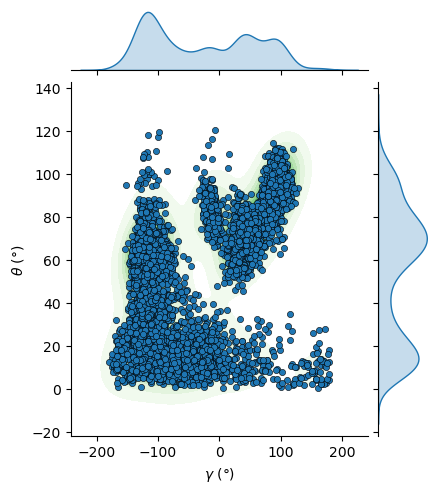

In [36]:
# Creazione del jointplot con KDE
g = sns.jointplot(
    data=df_rep0,
    x='phi',
    y='theta',
    kind="kde",
    fill=True,
    cmap="Greens",
    alpha=1,
    height=5,      # Altezza complessiva in pollici
    aspect=1.0     # Rapporto width/height
)

#g.fig.set_size_inches(figsize)


# Aggiungiamo il grafico a dispersione sul joint axis
scatter = g.ax_joint.scatter(
    df_rep0['phi'],
    df_rep0['theta'],
    edgecolor='k',
    s=20,
    linewidth=0.4
)

# Aggiustiamo il layout per lasciare spazio a destra per la colorbar
g.fig.subplots_adjust(right=0.85)

# Impostiamo le etichette con font leggibile e unità tra parentesi
g.set_axis_labels(r"$\gamma$ (°)", r"$\theta$ (°)")

# Impostazione dei limiti degli assi
#g.ax_joint.set_xlim(-300, 300)
#g.ax_joint.set_ylim(-10, 200)

# Personalizzazione dei tick e rimozione delle spine superiori e destre
#g.ax_joint.tick_params(direction="in", labelsize=9)
#g.ax_joint.spines["top"].set_visible(False)
#g.ax_joint.spines["right"].set_visible(False)
#plt.savefig("angles_glca.svg", format="svg", bbox_inches='tight')
plt.show()

In [75]:
u = mda.Universe('../PROD/ref_donor_domain.pdb', 'donor_domain.dcd')
reference = mda.Universe('../PROD/ref_bb.pdb')
reference_frame = reference.select_atoms('backbone').positions.copy()
reference_all=reference.select_atoms('all')
align.AlignTraj(u, reference, select='backbone', in_memory=True).run()
normal_vectors=[]
for ts in u.trajectory:
    ring=u.select_atoms('id 5231 5229 5228 5226 5225 5232')
    coords=ring.positions
    normal_vectors.append(get_normal_vector(coords))

np.savetxt('normal_vectors.txt', normal_vectors, header='Nx Ny Nz', comments='#')
ca_atoms=reference.select_atoms('name CA')
projections=[]
for i in range(len(normal_vectors)):
    projections.append(np.dot(ca_atoms.principal_axes(), normal_vectors[i]))
projections=np.array(projections)
polar=[]
for i in projections:
    polar.append(cartesian_to_spherical(i))

polar=np.array(polar).transpose()
phi, theta, r = polar
polar_system=np.array([phi, theta]).transpose()
df_polar = pd.DataFrame(
    polar_system,
    columns=["phi", "theta"]
)

df_polar.to_csv(
    "polar_data_G.csv",
    index=False
)

In [79]:
df_rep2 = pd.read_csv('polar_data_G.csv') 
df_rep2

,phi,theta
0,-121.688331,118.594683
1,-123.028259,124.006725
2,-125.115838,112.390338
3,-125.954169,120.067397
4,-123.889174,120.916108
...,...,...
4997,-126.764384,122.115438
4998,-116.690914,113.575990
4999,-122.723244,122.865057
5000,-130.264455,115.516194


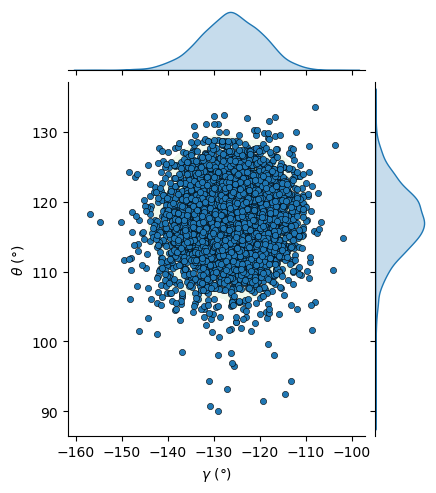

In [80]:
# Creazione del jointplot con KDE
g = sns.jointplot(
    data=df_rep2,
    x='phi',
    y='theta',
    kind="kde",
    fill=True,
    cmap="Greens",
    alpha=1,
    height=5,      # Altezza complessiva in pollici
    aspect=1.0     # Rapporto width/height
)

#g.fig.set_size_inches(figsize)


# Aggiungiamo il grafico a dispersione sul joint axis
scatter = g.ax_joint.scatter(
    df_rep2['phi'],
    df_rep2['theta'],
    edgecolor='k',
    s=20,
    linewidth=0.4
)

# Aggiustiamo il layout per lasciare spazio a destra per la colorbar
g.fig.subplots_adjust(right=0.85)

# Impostiamo le etichette con font leggibile e unità tra parentesi
g.set_axis_labels(r"$\gamma$ (°)", r"$\theta$ (°)")

# Impostazione dei limiti degli assi
#g.ax_joint.set_xlim(-300, 300)
#g.ax_joint.set_ylim(-10, 200)

# Personalizzazione dei tick e rimozione delle spine superiori e destre
#g.ax_joint.tick_params(direction="in", labelsize=9)
#g.ax_joint.spines["top"].set_visible(False)
#g.ax_joint.spines["right"].set_visible(False)
#plt.savefig("angles_glca.svg", format="svg", bbox_inches='tight')
plt.show()

### Contacts

In [62]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [63]:
protein = u.select_atoms("protein")
substrate = u.select_atoms("resname AMAN")

In [64]:
from MDAnalysis.analysis import contacts
ca = contacts.Contacts(
    u,
    select=(protein, substrate),
    refgroup=(protein, substrate),
    radius=4.5  # Å
)
ca.run()

Q = ca.results.timeseries[:,1]
np.save("native_contacts_Q_rep0.npy", Q)

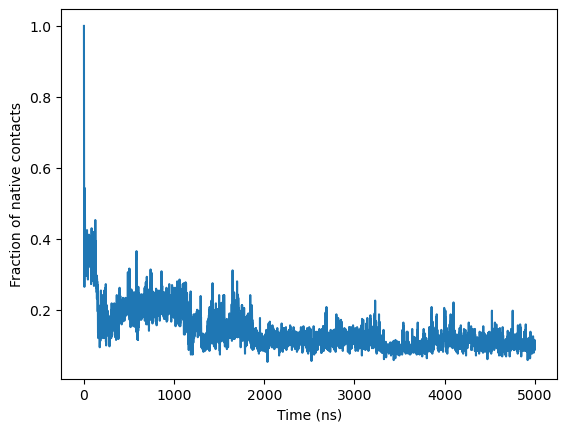

In [46]:
plt.plot( Q)  # ps → ns
plt.xlabel("Time (ns)")
plt.ylabel("Fraction of native contacts")
plt.show()